## PARIS inverse modelling results

This notebook contains options to plot and compare results from different inverse models. These variables can all be investigated:

- Posterior and prior country fluxes, total from all sectors
- Posterior, prior and observed modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior spatial fluxes

Future updates may include:

- Sector-level emissions
- Comparison between each model's country/region definition

### Notebook setup:

1. Edit the `data_dir` to point towards where the model output is.

2. Update the `model_filenames` dictionary to point towards the experiment/model you want to plot. Update the `model_labels` and `model_colors` dictionaries, these change how each model is labelled in the plots.

3. Run the cell below, before running any of the plotting code.

In [1]:
%load_ext autoreload
%autoreload 2
import PARIS_inversion_results as func

#data_dir = '/project/InTEM_GHG/inversion/PARIS_results_sharing/'
data_dir = '/home/h02/aramsden/results/multi_gas_MCMC/processed_output/'

model_filenames = {'rhime':'RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized_33sites*',
                  'rhime_edgar_allobs':'RHIME_NAME_EUROPE_EDGAR_all_obs*',
                  'mcmc':'MCMC_NAME_EUROPE',
                  'mcmc_d13':'MCMC_NAME_EUROPE_d13',
                  'mcmc_d13_fixedR':'MCMC_NAME_EUROPE_d13_fixedR',
                  'mcmc_d13_weighted':'MCMC_NAME_EUROPE_d13_weighted',
                  'mcmc_d13_highxuncert':'MCMC_NAME_EUROPE_d13_highxuncert',
                  'intem':'InTEM_NAME_EUROPE_5UK_site_test*',
                  'intem_14sites':'InTEM_NAME_EUROPE_EDGAR_14sites_new_obs'}

model_labels = {'rhime':'RHIME 33 site',
                  'rhime_edgar_allobs':'RHIME EDGAR all obs',
                  'mcmc':'MCMC',
                  'mcmc_d13':'MCMC d13',
                  'mcmc_d13_fixedR':'MCMC d13 fixedR',
                  'mcmc_d13_weighted':'MCMC d13 weighted',
                  'mcmc_d13_highxuncert':'MCMC d13 highxuncert',
                  'intem':'InTEM 5 site',
                  'intem_14sites':'InTEM 33 site'}

model_colors = {'rhime':['dimgrey','grey'],
                'rhime_edgar_allobs':['orange','gold'],
                'mcmc':['teal','lightskyblue'],
                'mcmc_d13':['darkblue','dodgerblue'],
                'mcmc_d13_fixedR':['purple','mediumpurple'],
                'mcmc_d13_weighted':['dimgrey','grey'],
                'mcmc_d13_highxuncert':['firebrick','darkorange'],
                'intem':['orange','goldenrod'],
                'intem_14sites':['orange','goldenrod']}

NOTE: If plotting units or scales look odd, edit species_info.json to fix this.


### 1. Timeseries of country/region fluxes

##### Edit and run this cell to choose inputs:

In [5]:
###################################
### edit variables in this block
species = 'ch4' #'hfc125'
plot_regions = ['UK','IRELAND','FRANCE','BELGIUM'] #works best with 6 countries but can run with any number (will always create at least 4 subplots though)
#model = ['mcmc','mcmc_2gas','mcmc_filtering','mcmc_new_model_error','mcmc_fixedbc','mcmc_fixed_outer',
#         'mcmc_old_setup','mcmc_2gas_old_setup','intem']
#models = ['mcmc','mcmc_filtering','mcmc_new_model_error','mcmc_fixedbc','mcmc_fixed_outer',
#         'mcmc_old_setup','intem']
models = ['intem_14sites','mcmc','mcmc_d13']
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2023-01-01' #inclusive
end_date = '2024-01-01' #not inclusive
###################################

ds_all_flux = func.read_flux(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_flux_scaled = {}

for m in models:
    ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,scale_units=True,
                                species=species)[m]


Attempting to read data from intem_14sites
Reading data from: /home/h02/aramsden/results/multi_gas_MCMC/processed_output/InTEM/ch4/InTEM_NAME_EUROPE_EDGAR_14sites_new_obs_ch4_monthly.nc
Done!

Attempting to read data from mcmc
Reading data from: /home/h02/aramsden/results/multi_gas_MCMC/processed_output/MCMC/ch4/MCMC_NAME_EUROPE_ch4_monthly.nc
Done!

Attempting to read data from mcmc_d13
Reading data from: /home/h02/aramsden/results/multi_gas_MCMC/processed_output/MCMC/ch4/MCMC_NAME_EUROPE_d13_ch4_monthly.nc
Done!

Masking data from intem_14sites
Scaling intem_14sites units by 1000000000.0

Masking data from mcmc
Scaling mcmc units by 1

Masking data from mcmc_d13
Scaling mcmc_d13 units by 1


#### Timeseries of country fluxes:

NOTE: If plotting units or scales look odd, edit species_info.json to fix this.


IndexError: list index out of range

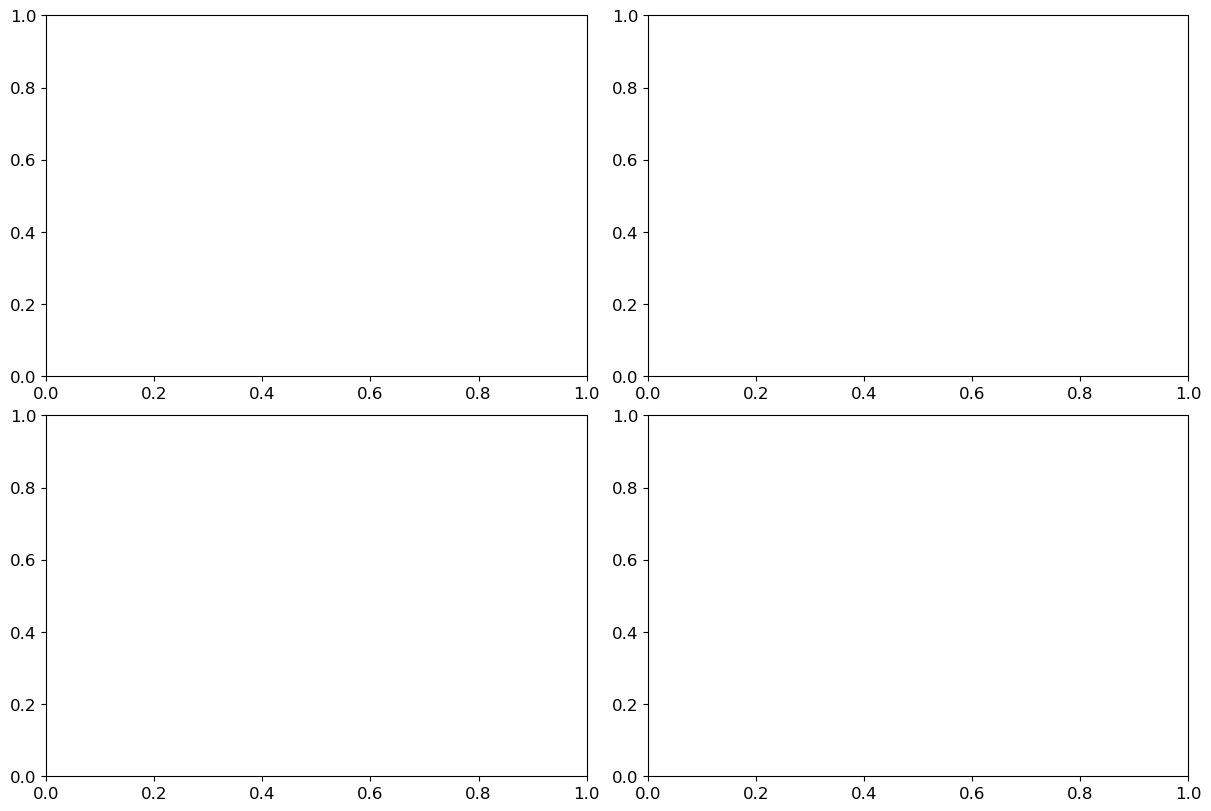

In [6]:
###################################
### edit variables in this block
plot_regions = ['IRELAND','UK','FRANCE','GERMANY'] #works best with 6 countries but can run with any number (will always create at least 4 subplots though)
plot_inventory = True
inventory_years = None #If None, plots most recent. Or can choose list of years: ['2022','2023']
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior_unc = False #if True: plots prior uncertainty as shaded area
set_global_leg = True #If True, plots one single legend instead of one legend per subplot.
country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles
plot_separate = True #If True, includes all model results as separate lines
plot_combined = False #If True, combined results, averaged from all models
plot_separate_by_year = True #If True, plot average flux over each year
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
###################################

fig = func.plot_country_flux(ds_all_flux_scaled,species,plot_regions,model_labels,
                             model_colors,
                             plot_inventory,inventory_years,data_dir,fix_y_axes,
                             add_prior_unc,set_global_leg,country_codes_as_titles=country_codes_as_titles,
                             plot_separate=plot_separate,plot_combined=plot_combined,
                             plot_separate_by_year=plot_separate_by_year,period_override=period_override)

Save plot here:

In [ ]:
output_path = '/home/h02/aramsden/results/multi_gas_MCMC/ch4_d13_dD/total_flux_results/post-country-fluxes_ch4_d13_weighted_highxuncert.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 2. Modelled and observed mole fractions and/or baselines

##### Edit and run this cell to choose inputs and read in the data:

In [ ]:
###################################
### edit variables in this block
species = 'ch4' 
site = 'HFD'
models = ['intem_14sites','mcmc','mcmc_d13','mcmc_d13_fixedR']
#models = ['intem','mcmc_prop-uncert','mcmc_prop-uncert-high-MHDbc_fixed-outer','mcmc_prop-uncert-high-MHDbc_fixed-outer_filtered']
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2022-01-01' #inclusive
end_date = '2024-01-01'   #not inclusive

baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
###################################

###################################
### options for variables to include in the functions below 
# Yobs          - total observed mole fraction
# uYobs         - total observed mole fraction uncertainty
# uYmod         - total model mole fraction uncertainty
# Yapriori      - prior total mole fraction
# Yapost        - posterior total mole fraction
# YaprioriBC    - prior baseline
# YapostBC      - posterior baseline
# Ybias         - posterior bias added to site
# YaprioriOuter - prior mole fractions only from outer regions
# YapostOuter   - posterior mole fractions only from outer regions
###################################

ds_all_mf = func.read_mf(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_mf_sliced = {}

for m in models:
    ds_all_mf_sliced[m] = func.slice_mf({m:ds_all_mf[m]},start_date,end_date,site,baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)[m]

#### Timeseries plot, separated by model:

In [ ]:
fig = func.plot_obs_modelled_separate(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yobs','YapostBC','YaprioriBC'],
                             diff_include=['YapostBC','YaprioriBC'],
                             y_lim=None)

###################################
### Instructions for timeseries plotting: 
# - Add variables that you want to plot in "include"
# - To plot the histogram of the variables in "include", leave "diff_include" empty
# - To plot the histogram of Obs-variable, add the desired variable to be subtracted in "diff_include" (default value of "diff_include" = Yapost)
# - To erase uncertainty bars around the mean values of Yobs and Yapost set "add_unc" to False (default value of "add_unc" = True)
###################################

In [ ]:
output_path = '/home/h02/aramsden/results/multi_gas_MCMC/ch4_d13_dD/total_flux_results/YapostBC_HFD_ch4_d13_weighted_highxuncert'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, all models together:

In [ ]:
fig = func.plot_obs_modelled_together(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['YapostBC'],
                             diff_include=['YapostBC'],
                             y_lim=None)

#### Absolute differences between two models:

In [ ]:
fig = func.plot_obs_diff(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yapost'],
                             diff_include=['Yapost'])

#### Calculate and plot stats for the fit to obs:

In [ ]:
ds_all_allsites = func.slice_mf(ds_all_mf.copy(),start_date,end_date,site=None,
                              baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

pearson,nrmse = func.stats_mf(ds_all_allsites,species)

fig = func.plot_stats_mf(pearson,nrmse,species,model_labels,
                         model_colors,
                  start_date=start_date,end_date=end_date)

Save plot:

In [ ]:
output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 3. Posterior country fluxes - lat lon grid prior and posterior comparison

##### Edit this cell to choose inputs:

In [ ]:
###################################
### edit variables in this block
species = 'ch4'
start_date = '2023-04-01' #select the time period to plot (a month or year, depending on the inversion period)
end_date = '2023-05-01' #if end_date doesn't = start_date, a mean average of the whole period will be plotted
#models = ['intem','mcmc_old_setup','mcmc','mcmc_2gas']
#sectors = [['total'],['total'],['total'],['FF','nonFF']]
models = ['intem','mcmc','mcmc_d13','mcmc_d13']
#sectors = [['FF','nonFF'],['FF','nonFF'],['FF','nonFF'],['FF','nonFF']] # list of list of sector names, for each model
sectors = [['total'],['FF','nonFF'],['FF','nonFF'],['FF','nonFF'],['FF','nonFF']] # list of list of sector names, for each model
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
###################################

ds_all_flux = func.read_flux(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_flux_scaled = {}

for m in models:

    ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,scale_units=True,
                                    species=species)[m]

##### Prior and posterior fluxes for all models:

In [ ]:
###################################
### edit variables in this block
plot_area = 'NWEU' #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE
###################################

fig = func.plot_spatial_flux(ds_all_flux_scaled,species,plot_area,model_labels,
                             sectors=sectors,cmap='viridis',
                             cmap_diff='bwr',c_border='floralwhite')

In [ ]:
output_path = '/home/h02/aramsden/results/multi_gas_MCMC/ch4_d13_dD/total_flux_results/spatial_flux_nonFF_ch4_d13_weighted_highxuncert'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

##### Directly compare posterior fluxes from two models:

In [ ]:
fig = func.plot_spatial_flux_comparison(ds_all_flux_scaled,species,plot_area,model_labels)

### 7. Compare region definitions

THIS NEEDS UPDATING TO COMPARE MULTIPLE MODELS - CURRENTLY THESE NEED TO BE INPUT MANUALLY

In [ ]:
species = 'ch4' #select the species you want to plot
plot_region = 'UK' #choose the region mask to plot

In [ ]:
# Read in emissions output

intem = xr.open_dataset(os.path.join(data_dir,f'InTEM_NAME_EUROPE_{intem_species[species]}_{period[m][species]}.nc'))
#rhime = xr.open_dataset(os.path.join(data_dir,f'RHIME_NAME_EUROPE_{species}_{period}.nc'))
#empa = xr.open_dataset(os.path.join(data_dir,f'{empa_name}_FLEXPART_EUROPE_{species}_{period}.nc')) 

try:
    intem_r0 = np.where(intem['countrynames'].values == plot_region)[0][0]
except:
    print(f'No region in InTEM called {plot_region}')

In [ ]:
ax_limits = [-12,25,40,65] #min_lon, max_lon, min_lat, max_lat

fig,ax = plt.subplots(2,3,figsize=(12,6),constrained_layout=True,
                          subplot_kw={'projection':cartopy.crs.PlateCarree()})

for i in range(2):
    for j in range(3):
        ax[i,j].add_feature(cartopy.feature.BORDERS,linestyle=':',edgecolor='black',linewidth=1.)
        ax[i,j].coastlines(resolution='50m',color='black',linewidth=1.)
        ax[i,j].set_extent(ax_limits)
        
#plot intem
ax[0,0].pcolormesh(intem.lon.values,intem.lat.values,intem['region_definitions'][:,:,intem_r0],cmap='Blues',
                 vmin=0,vmax=2)
ax[0,0].set_title(f'InTEM {plot_region} mask')

#plot difference
#ax[1,0].pcolormesh(intem.lon.values,intem.lat.values,
#                   intem['region_definitions'][:,:,intem_r0]-rhime['region_definitions'][:,:,rhime_r0],
#                   cmap='bwr')
ax[1,0].set_title(f'InTEM {plot_region} - RHIME {plot_region}')